In [6]:
from pathlib import Path
import pandas as pd

file_path_m = Path.home() / "Downloads" / "mechanisms.xlsx"
mechanisms = pd.read_excel(file_path_m)

file_path_t = Path.home() / "Downloads" / "triggers.xlsx"
triggers = pd.read_excel(file_path_t)


mechanisms.head()

,Table 1.6.2-2Mechanisms of injury for US and Canadian scuba fatalities,Unnamed: 1,Unnamed: 2,Unnamed: 3,Unnamed: 4,Unnamed: 5,Unnamed: 6,Unnamed: 7,Unnamed: 8,Unnamed: 9
0,Mechanism,2016,2015,2014,2010,2011,2012,2013,2017,2018
1,Breathing Issues/ Out of air,2,0,3,7,9,7,10,2,1
2,Panic,3,1,0,0,2,5,0,0,0
3,Ascent/ Pressure-related,3,5,2,19,8,4,2,4,4
4,Exhaustion,2,0,0,0,0,1,1,0,0


In [17]:
file_path_r = Path.home() / "Downloads" / "region_country.xlsx"
region_country = pd.read_excel(file_path_r)

file_path_max = Path.home() / "Downloads" / "max_depth.xlsx"
max_depth = pd.read_excel(file_path_max)

file_path_certifications = Path.home() / "Downloads" / "certifications.xlsx"
certifications = pd.read_excel(file_path_certifications)

In [13]:
print("region_country shape:", region_country.shape)
print("columns:", list(region_country.columns))
display(region_country.head(10))

region_country shape: (100, 12)
columns: ['Region', 'country', 'number 2016', 2010, 2011, 2012, 2013, 2014, 2015, 2017, 2019, 2020]


,Region,country,number 2016,2010,2011,2012,2013,2014,2015,2017,2019,2020
0,North America,NaN,72.0,62,90,73,67,60,46,85,77,58
1,NaN,United States,59.0,56,74,56,48,50,39,71,67,49
2,NaN,Mexico,8.0,1,9,9,8,6,2,6,5,3
3,NaN,Canada,5.0,4,6,7,10,4,4,8,5,6
4,NaN,Bermuda,0.0,0,1,1,1,0,1,0,0,0
5,NaN,Greenland,0.0,1,0,0,0,0,0,0,0,0
6,Oceania,NaN,23.0,12,18,11,19,14,18,24,25,18
7,NaN,Australia,14.0,6,11,7,11,5,8,7,14,9
8,NaN,French Polynesia,0.0,0,0,0,0,0,1,3,0,1
9,NaN,Marshall Island,0.0,0,0,0,0,0,1,0,0,0


,Region,year,fatalities,total_fatalities,proportion
0,North America,2010,62.0,117.0,0.529915
1,Oceania,2010,12.0,117.0,0.102564
2,Caribbean,2010,6.0,117.0,0.051282
3,South America,2010,1.0,117.0,0.008547
4,Northern Africa,2010,4.0,117.0,0.034188


,Region,country,year,fatalities,total_fatalities,proportion
0,North America,United States,2010,56.0,117.0,0.478632
1,North America,Mexico,2010,1.0,117.0,0.008547
2,North America,Canada,2010,4.0,117.0,0.034188
3,North America,Bermuda,2010,0.0,117.0,0.000000
4,North America,Greenland,2010,1.0,117.0,0.008547


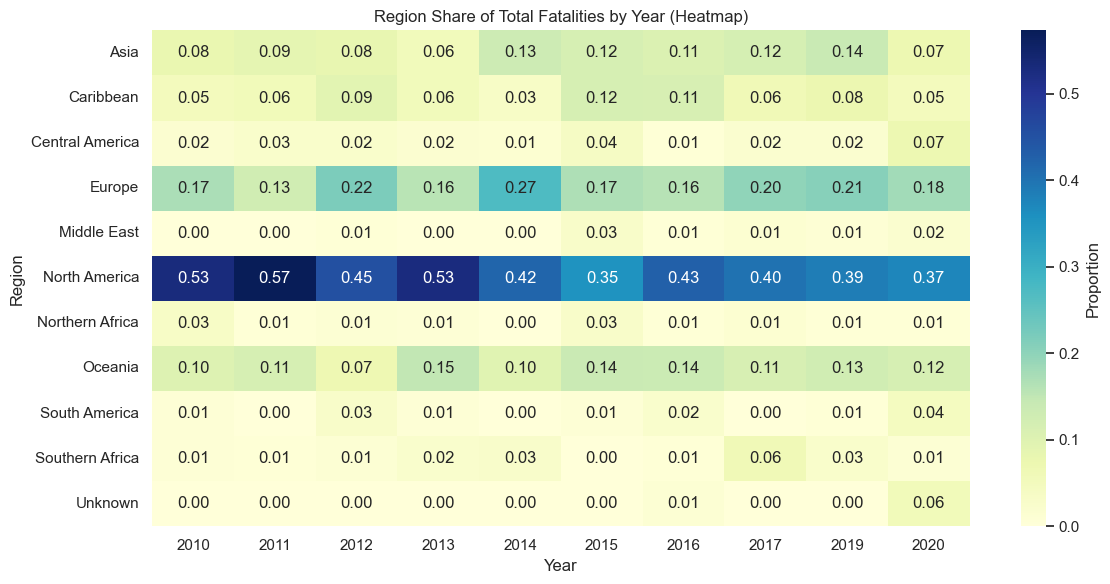

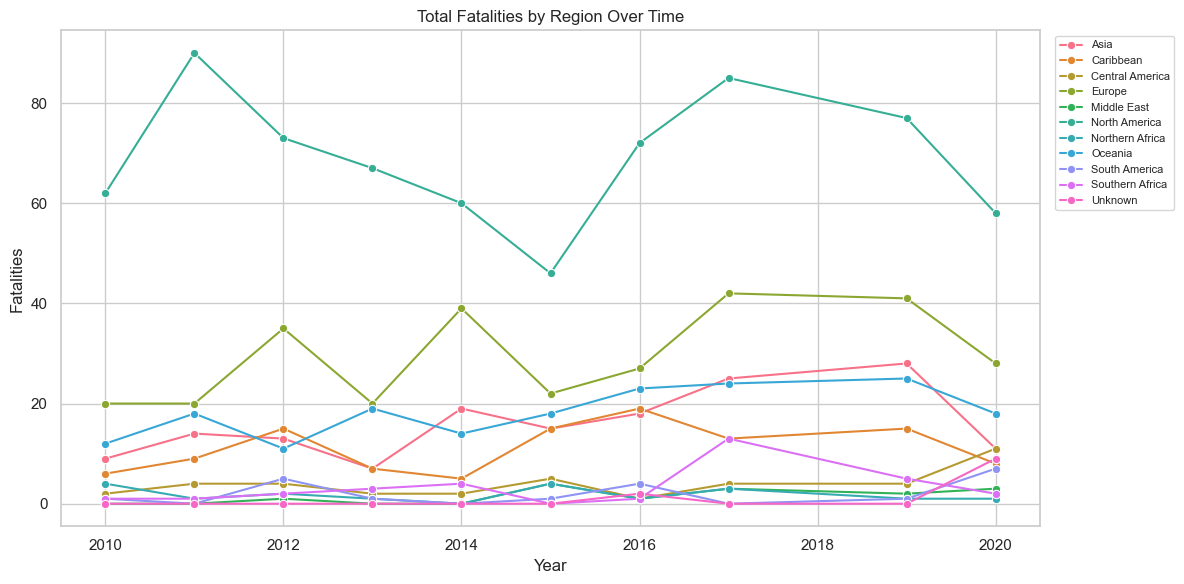

Top 10 countries by total fatalities:


,country,fatalities
78,United States,569.0
2,Australia,92.0
77,United Kingdom,69.0
11,Canada,59.0
44,Mexico,57.0
50,New Zealand,52.0
36,Italy,37.0
54,Philippines,31.0
52,Other,31.0
34,Indonesia,31.0


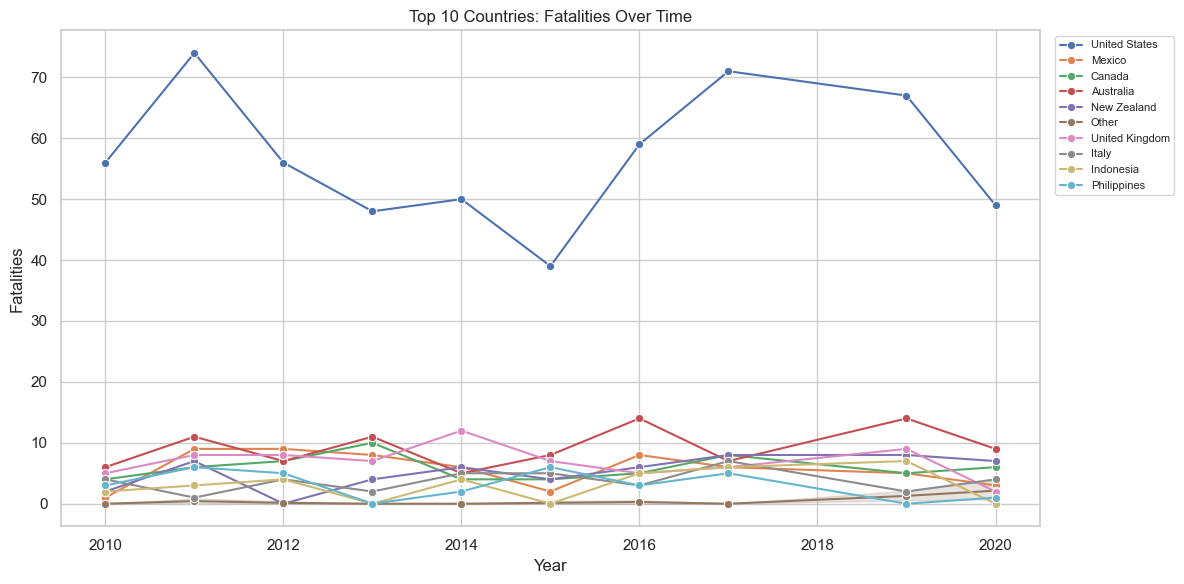

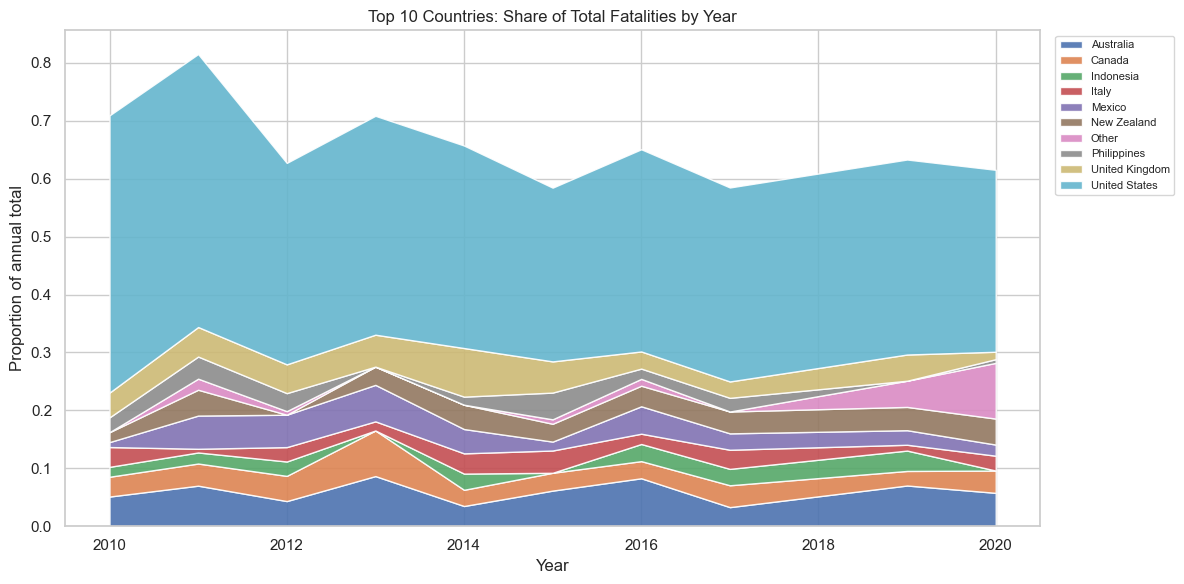

In [15]:
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

###reshaping
rc = region_country.copy()
rc.columns = [str(c).strip() for c in rc.columns]


year_map = {}
for col in rc.columns:
    m = re.search(r"(19\d{2}|20\d{2})", str(col))
    if m:
        year_map[col] = int(m.group(1))

if not year_map:
    raise ValueError("No year columns found in region_country")

rc = rc.rename(columns=year_map)
year_cols = sorted([c for c in rc.columns if isinstance(c, int)])

#fwrd fill region name to country rows
rc["Region"] = rc["Region"].ffill()

##region total rows are those with no country value
region_rows = rc[rc["country"].isna()].copy()
country_rows = rc[rc["country"].notna()].copy()


region_long = region_rows.melt(id_vars=["Region"], value_vars=year_cols, var_name="year", value_name="fatalities")
region_long["fatalities"] = pd.to_numeric(region_long["fatalities"], errors="coerce").fillna(0)
region_long["year"] = region_long["year"].astype(int)

country_long = country_rows.melt(id_vars=["Region", "country"], value_vars=year_cols, var_name="year", value_name="fatalities")
country_long["fatalities"] = pd.to_numeric(country_long["fatalities"], errors="coerce").fillna(0)
country_long["year"] = country_long["year"].astype(int)

#totals by year from region totals
year_totals = region_long.groupby("year", as_index=False)["fatalities"].sum().rename(columns={"fatalities": "total_fatalities"})

###proportions of total by year
region_prop = region_long.merge(year_totals, on="year", how="left")
region_prop["proportion"] = np.where(region_prop["total_fatalities"] > 0, region_prop["fatalities"] / region_prop["total_fatalities"], 0)

country_prop = country_long.merge(year_totals, on="year", how="left")
country_prop["proportion"] = np.where(country_prop["total_fatalities"] > 0, country_prop["fatalities"] / country_prop["total_fatalities"], 0)


display(region_prop.head())
display(country_prop.head())

# CHART 1: Region share of total fatalities by year (heatmap)
region_share_heatmap = (
    region_prop.pivot_table(index="Region", columns="year", values="proportion", aggfunc="sum", fill_value=0)
    .sort_index()
)
plt.figure(figsize=(12, 6))
sns.heatmap(region_share_heatmap, cmap="YlGnBu", annot=True, fmt=".2f", cbar_kws={"label": "Proportion"})
plt.title("Region Share of Total Fatalities by Year (Heatmap)")
plt.xlabel("Year")
plt.ylabel("Region")
plt.tight_layout()
plt.show()

# CHART 2: Totals of fatalities by region over time (separate chart)
region_totals_ts = region_long.groupby(["year", "Region"], as_index=False)["fatalities"].sum()
plt.figure(figsize=(12, 6))
sns.lineplot(data=region_totals_ts, x="year", y="fatalities", hue="Region", marker="o")
plt.title("Total Fatalities by Region Over Time")
plt.xlabel("Year")
plt.ylabel("Fatalities")
plt.legend(loc="upper left", bbox_to_anchor=(1.01, 1), fontsize=8)
plt.tight_layout()
plt.show()

#top 10 countries by total fatalities
top10_countries = (
    country_long.groupby("country", as_index=False)["fatalities"]
    .sum()
    .sort_values("fatalities", ascending=False)
    .head(10)
)
print("Top 10 countries by total fatalities:")
display(top10_countries)

top10_list = top10_countries["country"].tolist()
top10_country_ts = country_long[country_long["country"].isin(top10_list)].copy()

# ---------- Chart 3: Top 10 countries fatalities over time ----------
plt.figure(figsize=(12, 6))
sns.lineplot(data=top10_country_ts, x="year", y="fatalities", hue="country", marker="o")
plt.title("Top 10 Countries: Fatalities Over Time")
plt.xlabel("Year")
plt.ylabel("Fatalities")
plt.legend(loc="upper left", bbox_to_anchor=(1.01, 1), fontsize=8)
plt.tight_layout()
plt.show()

# proportions for top 10 countries
top10_country_prop = country_prop[country_prop["country"].isin(top10_list)].copy()
top10_prop_pivot = top10_country_prop.pivot_table(index="year", columns="country", values="proportion", aggfunc="sum", fill_value=0).sort_index()
plt.figure(figsize=(12, 6))
plt.stackplot(top10_prop_pivot.index, top10_prop_pivot.values.T, labels=top10_prop_pivot.columns, alpha=0.9)
plt.title("Top 10 Countries: Share of Total Fatalities by Year")
plt.xlabel("Year")
plt.ylabel("Proportion of annual total")
plt.legend(loc="upper left", bbox_to_anchor=(1.01, 1), fontsize=8)
plt.tight_layout()
plt.show()

Most common max depth categories (overall):


,category,count
4,up to 30 ft,79
0,31-60,75
1,61-90,52
3,more than 120,49
2,91-120,40


/var/folders/sr/8ckh5m7s1xq7sqkrncq1q2l80000gn/T/ipykernel_71958/3772381036.py:45: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=max_depth_overall, x="count", y="category", palette="viridis")


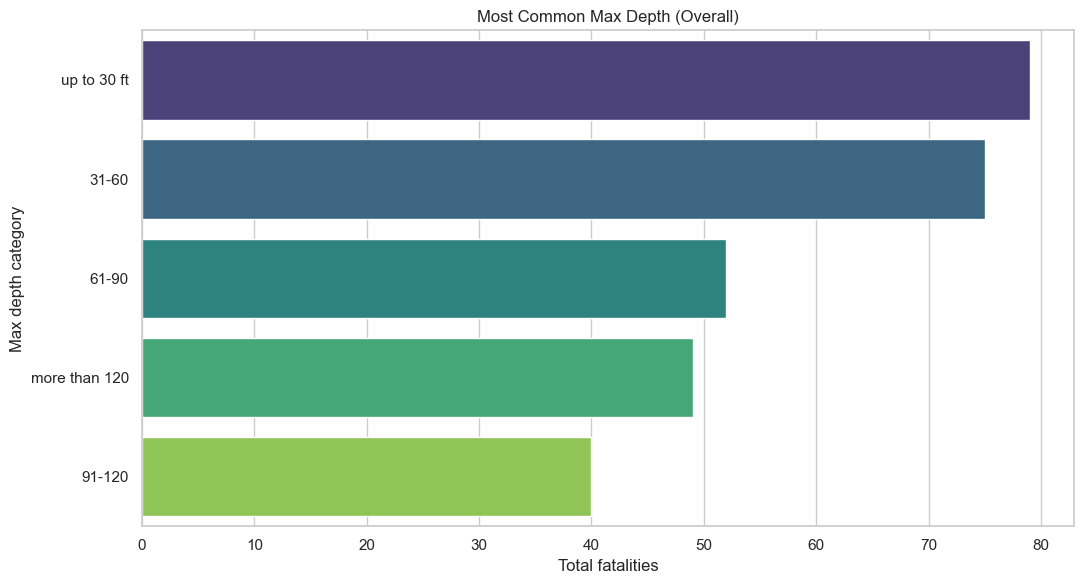

/var/folders/sr/8ckh5m7s1xq7sqkrncq1q2l80000gn/T/ipykernel_71958/3772381036.py:55: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  max_depth_ts = max_depth_top.groupby(["period", "category"], as_index=False)["count"].sum()


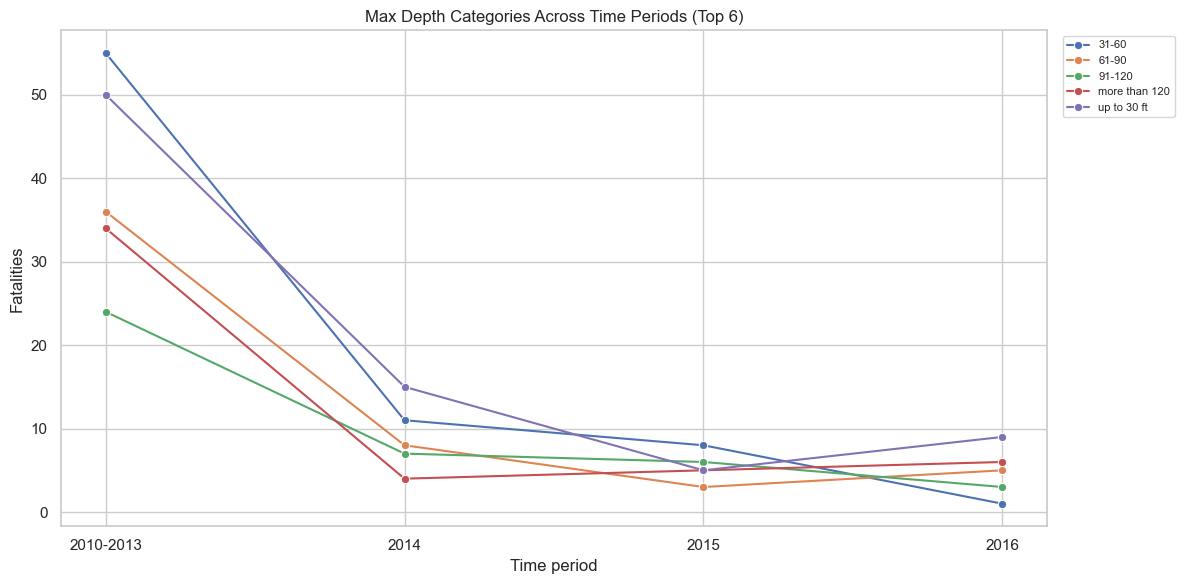

In [ ]:
#Max depth
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

md = max_depth.copy()
md.columns = [str(c).strip() for c in md.columns]

# Identify columns
category_col = next((c for c in md.columns if "max depth" in c.lower()), md.columns[1])
time_cols = [c for c in md.columns if re.search(r"^\d{4}(?:-\d{4})?$", str(c).strip())]

if not time_cols:
    raise ValueError(f"No year/time-period columns found in max_depth. Columns: {list(md.columns)}")

#long table
max_depth_long = md.melt(id_vars=[category_col], value_vars=time_cols, var_name="period", value_name="count")
max_depth_long = max_depth_long.rename(columns={category_col: "category"})
max_depth_long["category"] = max_depth_long["category"].astype(str).str.strip()
max_depth_long["count"] = pd.to_numeric(max_depth_long["count"], errors="coerce")
max_depth_long = max_depth_long.dropna(subset=["count", "category"])


max_depth_long = max_depth_long[~max_depth_long["category"].str.lower().isin(["max depth", "total", "nan"])]
max_depth_long = max_depth_long[~max_depth_long["category"].str.lower().str.startswith("table")]

#Order periods (by starting year)
period_order = sorted(max_depth_long["period"].unique(), key=lambda x: int(str(x).split("-")[0]))
max_depth_long["period"] = pd.Categorical(max_depth_long["period"], categories=period_order, ordered=True)

#Most common max depth overall
max_depth_overall = (
    max_depth_long.groupby("category", as_index=False)["count"]
    .sum()
    .sort_values("count", ascending=False)
)
print("Most common max depth categories (overall):")
display(max_depth_overall)

plt.figure(figsize=(11, 6))
sns.barplot(data=max_depth_overall, x="count", y="category", palette="viridis")
plt.title("Most Common Max Depth (Overall)")
plt.xlabel("Total fatalities")
plt.ylabel("Max depth category")
plt.tight_layout()
plt.show()

#Across periods: top 6 categories over time
top_depth_categories = max_depth_overall.head(6)["category"].tolist()
max_depth_top = max_depth_long[max_depth_long["category"].isin(top_depth_categories)].copy()
max_depth_ts = max_depth_top.groupby(["period", "category"], as_index=False)["count"].sum()

plt.figure(figsize=(12, 6))
sns.lineplot(data=max_depth_ts, x="period", y="count", hue="category", marker="o")
plt.title("Max Depth Categories Across Time Periods (Top 6)")
plt.xlabel("Time period")
plt.ylabel("Fatalities")
plt.legend(loc="upper left", bbox_to_anchor=(1.01, 1), fontsize=8)
plt.tight_layout()
plt.show()

Top 5 categories by proportion for each year and section:


,section,year,category,proportion
75,Mechanism,2010,Other,0.426471
21,Mechanism,2010,Ascent/ Pressure-related,0.279412
84,Mechanism,2010,Unknown,0.176471
3,Mechanism,2010,Breathing Issues/ Out of air,0.102941
156,Mechanism,2010,Buoyancy,0.014706
...,...,...,...,...
261,Trigger,2019,Breathing issues/ Choking,0.407407
201,Trigger,2019,Equipment,0.185185
181,Trigger,2019,Health problem,0.111111
191,Trigger,2019,Gas Toxicity,0.074074


Top 5 categories overall by section:


,section,category,proportion
17,Mechanism,Unknown,0.539652
0,Mechanism,Ascent/ Pressure-related,0.098646
13,Mechanism,Other,0.094778
1,Mechanism,Breathing Issues/ Out of air,0.079304
8,Mechanism,Gas Toxicity,0.042553
32,Trigger,Unknown,0.526978
27,Trigger,Health problem,0.100719
24,Trigger,Equipment,0.068345
19,Trigger,Breathing issues/ Choking,0.055755
26,Trigger,Gas Toxicity,0.044964


/var/folders/sr/8ckh5m7s1xq7sqkrncq1q2l80000gn/T/ipykernel_71958/106134003.py:99: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=sub, x="proportion", y="category", ax=axes[i], palette="mako")
/var/folders/sr/8ckh5m7s1xq7sqkrncq1q2l80000gn/T/ipykernel_71958/106134003.py:99: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=sub, x="proportion", y="category", ax=axes[i], palette="mako")


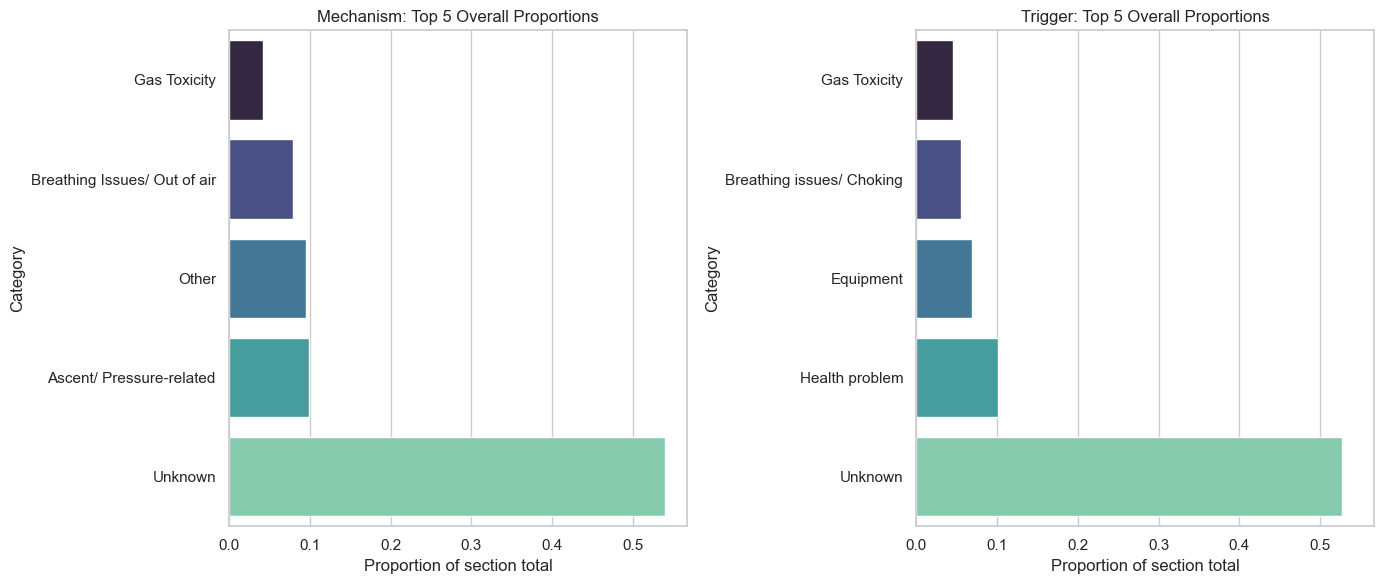

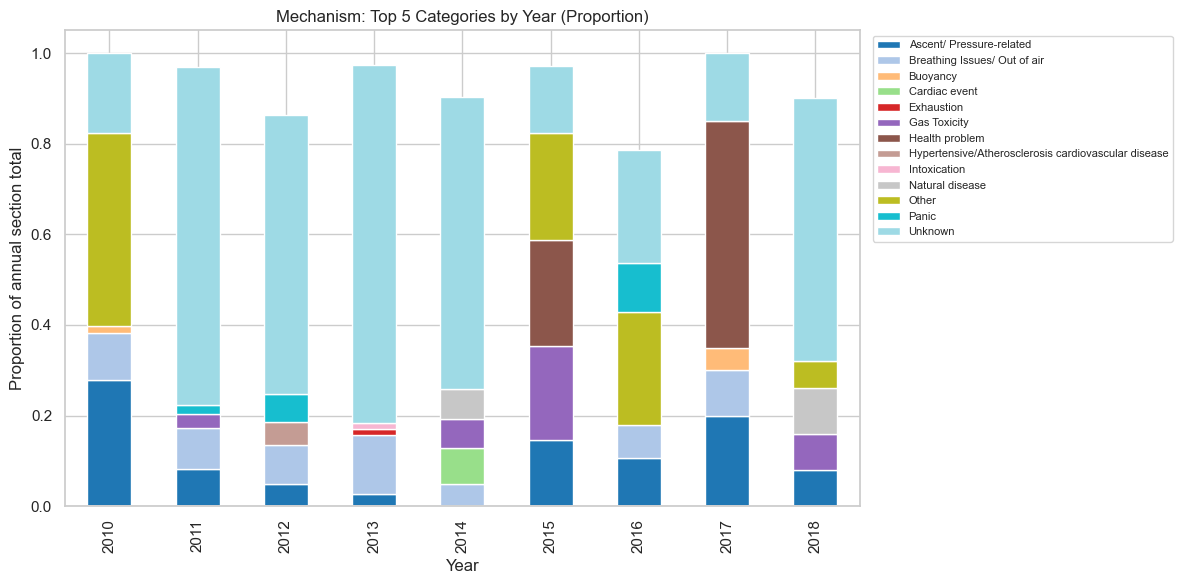

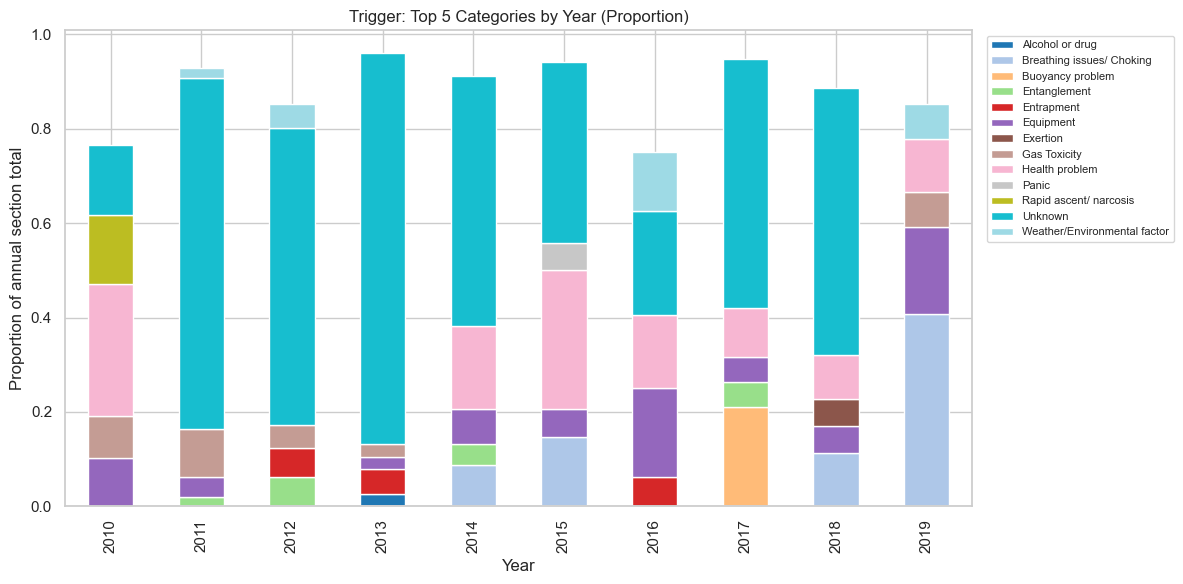

In [ ]:
#Trigger + Mechanism analysis in a different cell: top 5 by yearly proportion and overall


## TODO Misspellings need to fix
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

def _year_from_value(value):
    if pd.isna(value):
        return None
    if isinstance(value, (int, np.integer)):
        year = int(value)
        return year if 1900 <= year <= 2100 else None
    if isinstance(value, (float, np.floating)) and float(value).is_integer():
        year = int(value)
        return year if 1900 <= year <= 2100 else None
    text = str(value).strip()
    match = re.fullmatch(r"(\d{4})(?:\.0+)?", text)
    if match:
        year = int(match.group(1))
        return year if 1900 <= year <= 2100 else None
    return None

def parse_wide_section_table(df, section_name):
    raw = df.copy().dropna(how="all").reset_index(drop=True)
    raw.columns = [str(c).strip() for c in raw.columns]

    header_idx = None
    year_cols = {}
    for ridx in range(min(12, len(raw))):
        candidate = {}
        for cidx, val in raw.iloc[ridx].items():
            y = _year_from_value(val)
            if y is not None:
                candidate[cidx] = y
        if len(candidate) >= 3:
            header_idx = ridx
            year_cols = candidate
            break

    if header_idx is None:
        raise ValueError(f"Could not detect year header row for {section_name}")

    rows = []
    for ridx in range(header_idx + 1, len(raw)):
        category = raw.iloc[ridx, 0]
        if pd.isna(category):
            continue
        category = str(category).strip()
        if not category or category.lower() in {"total", "nan"}:
            continue
        for cidx, year in year_cols.items():
            value = pd.to_numeric(raw.loc[ridx, cidx], errors="coerce")
            if pd.isna(value):
                continue
            rows.append({
                "section": section_name,
                "category": category,
                "year": int(year),
                "count": float(value),
            })

    out = pd.DataFrame(rows)
    if out.empty:
        raise ValueError(f"No usable rows parsed for {section_name}")
    return out

mechanism_long_2 = parse_wide_section_table(mechanisms, "Mechanism")
trigger_long_2 = parse_wide_section_table(triggers, "Trigger")
tm_long = pd.concat([mechanism_long_2, trigger_long_2], ignore_index=True)

#Yearly proportions
year_totals_tm = tm_long.groupby(["section", "year"], as_index=False)["count"].sum().rename(columns={"count": "year_total"})
tm_year_prop = tm_long.merge(year_totals_tm, on=["section", "year"], how="left")
tm_year_prop["proportion"] = np.where(tm_year_prop["year_total"] > 0, tm_year_prop["count"] / tm_year_prop["year_total"], 0)

top5_yearly = (
    tm_year_prop.sort_values(["section", "year", "proportion"], ascending=[True, True, False])
    .groupby(["section", "year"], as_index=False)
    .head(5)
)
print("Top 5 categories by proportion for each year and section:")
display(top5_yearly[["section", "year", "category", "proportion"]].sort_values(["section", "year", "proportion"], ascending=[True, True, False]))

#Overall proportions
overall_totals_tm = tm_long.groupby("section", as_index=False)["count"].sum().rename(columns={"count": "overall_total"})
tm_overall = tm_long.groupby(["section", "category"], as_index=False)["count"].sum().merge(overall_totals_tm, on="section", how="left")
tm_overall["proportion"] = np.where(tm_overall["overall_total"] > 0, tm_overall["count"] / tm_overall["overall_total"], 0)
top5_overall = tm_overall.sort_values(["section", "proportion"], ascending=[True, False]).groupby("section", as_index=False).head(5)
print("Top 5 categories overall by section:")
display(top5_overall[["section", "category", "proportion"]].sort_values(["section", "proportion"], ascending=[True, False]))

##### TO DO: Remove Unknown and replace with proportions of total for others

## TO DO: clean up visualizations, 

#GRAPH: Overall top 5 proportions for Trigger and Mechanism
fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharex=True)
for i, sec in enumerate(["Mechanism", "Trigger"]):
    sub = top5_overall[top5_overall["section"] == sec].sort_values("proportion", ascending=True)
    sns.barplot(data=sub, x="proportion", y="category", ax=axes[i], palette="mako")
    axes[i].set_title(f"{sec}: Top 5 Overall Proportions")
    axes[i].set_xlabel("Proportion of section total")
    axes[i].set_ylabel("Category")
plt.tight_layout()
plt.show()

#GRAPH: Yearly top 5 proportions (stacked bars)
for sec in ["Mechanism", "Trigger"]:
    sub = top5_yearly[top5_yearly["section"] == sec].copy()
    pivot = sub.pivot_table(index="year", columns="category", values="proportion", aggfunc="sum", fill_value=0).sort_index()
    plt.figure(figsize=(12, 6))
    pivot.plot(kind="bar", stacked=True, ax=plt.gca(), colormap="tab20")
    plt.title(f"{sec}: Top 5 Categories by Year (Proportion)")
    plt.xlabel("Year")
    plt.ylabel("Proportion of annual section total")
    plt.legend(loc="upper left", bbox_to_anchor=(1.01, 1), fontsize=8)
    plt.tight_layout()
    plt.show()